# Position Tracking — ADAPT Hand (15 DOF)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys

sys.path.insert(0, os.path.join('..'))
plt.style.use(os.path.join('..', 'plot_config.mplstyle'))

DATA_DIR = os.path.join('outputs')
PDF_DIR  = os.path.join(DATA_DIR, 'pdfs')
os.makedirs(PDF_DIR, exist_ok=True)

POSES    = [1, 2]
LABELS   = ['PC1', 'PC2']

def load_pose(pose_id, label):
    path = os.path.join(DATA_DIR, f'pose{pose_id}_{label}.csv')
    if not os.path.exists(path):
        raise FileNotFoundError(f'No data for pose {pose_id} ({label})')
    return pd.read_csv(path)

dfs = {i+1: load_pose(i+1, LABELS[i]) for i in range(2)}
print('Loaded:', {k: len(v) for k, v in dfs.items()}, 'rows per pose')

Loaded: {1: 540, 2: 540} rows per pose


In [22]:
GROUPS = {
    'Wrist':         ['wrist_pitch',  'wrist_yaw'],
    'Thumb':         ['thumb_CMC1',   'thumb_CMC2',  'thumb_MCP',  'thumb_IP'],
    'Spread':        ['spread_index', 'spread_middle', 'spread_ring', 'spread_pinky'],
    'Index finger':  ['index_MCP',   'index_PIP',   'index_DIP'],
    'Middle finger': ['middle_MCP',  'middle_PIP',  'middle_DIP'],
    'Ring finger':   ['ring_MCP',    'ring_PIP',    'ring_DIP'],
    'Pinky finger':  ['pinky_MCP',   'pinky_PIP',   'pinky_DIP'],
}
COLORS = ['tab:blue', 'tab:orange']

## Joint-space tracking performance

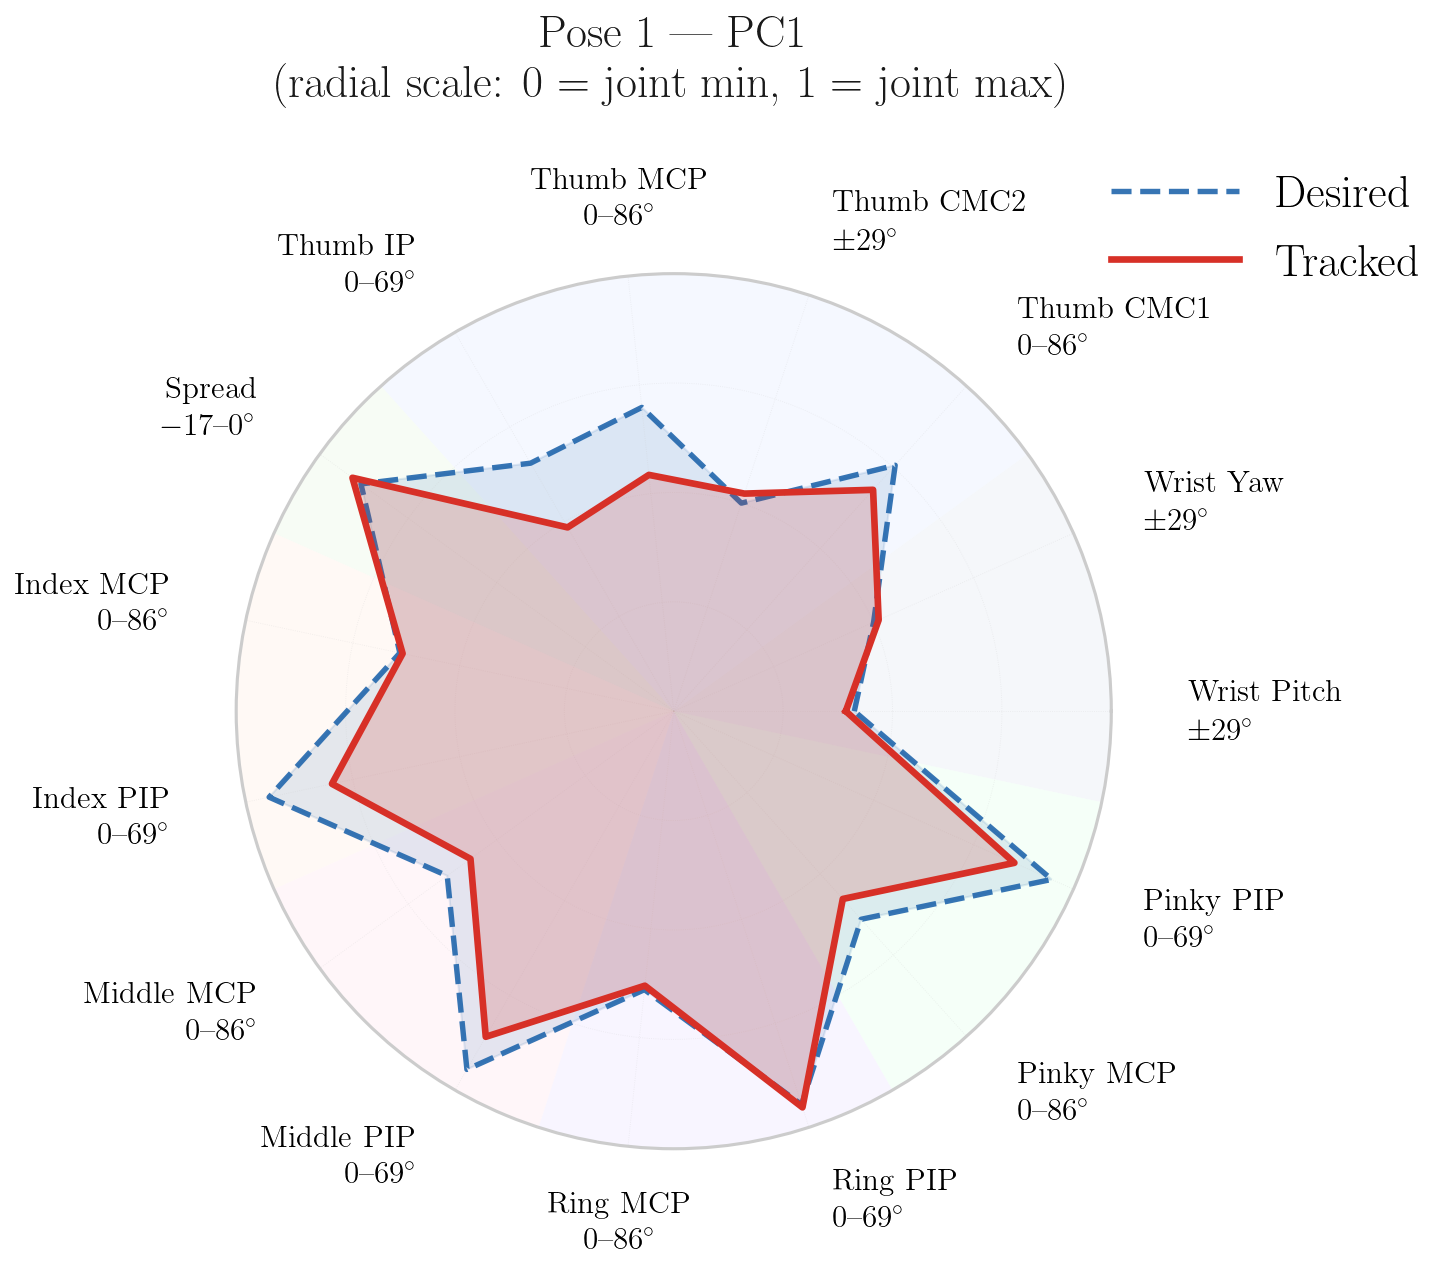

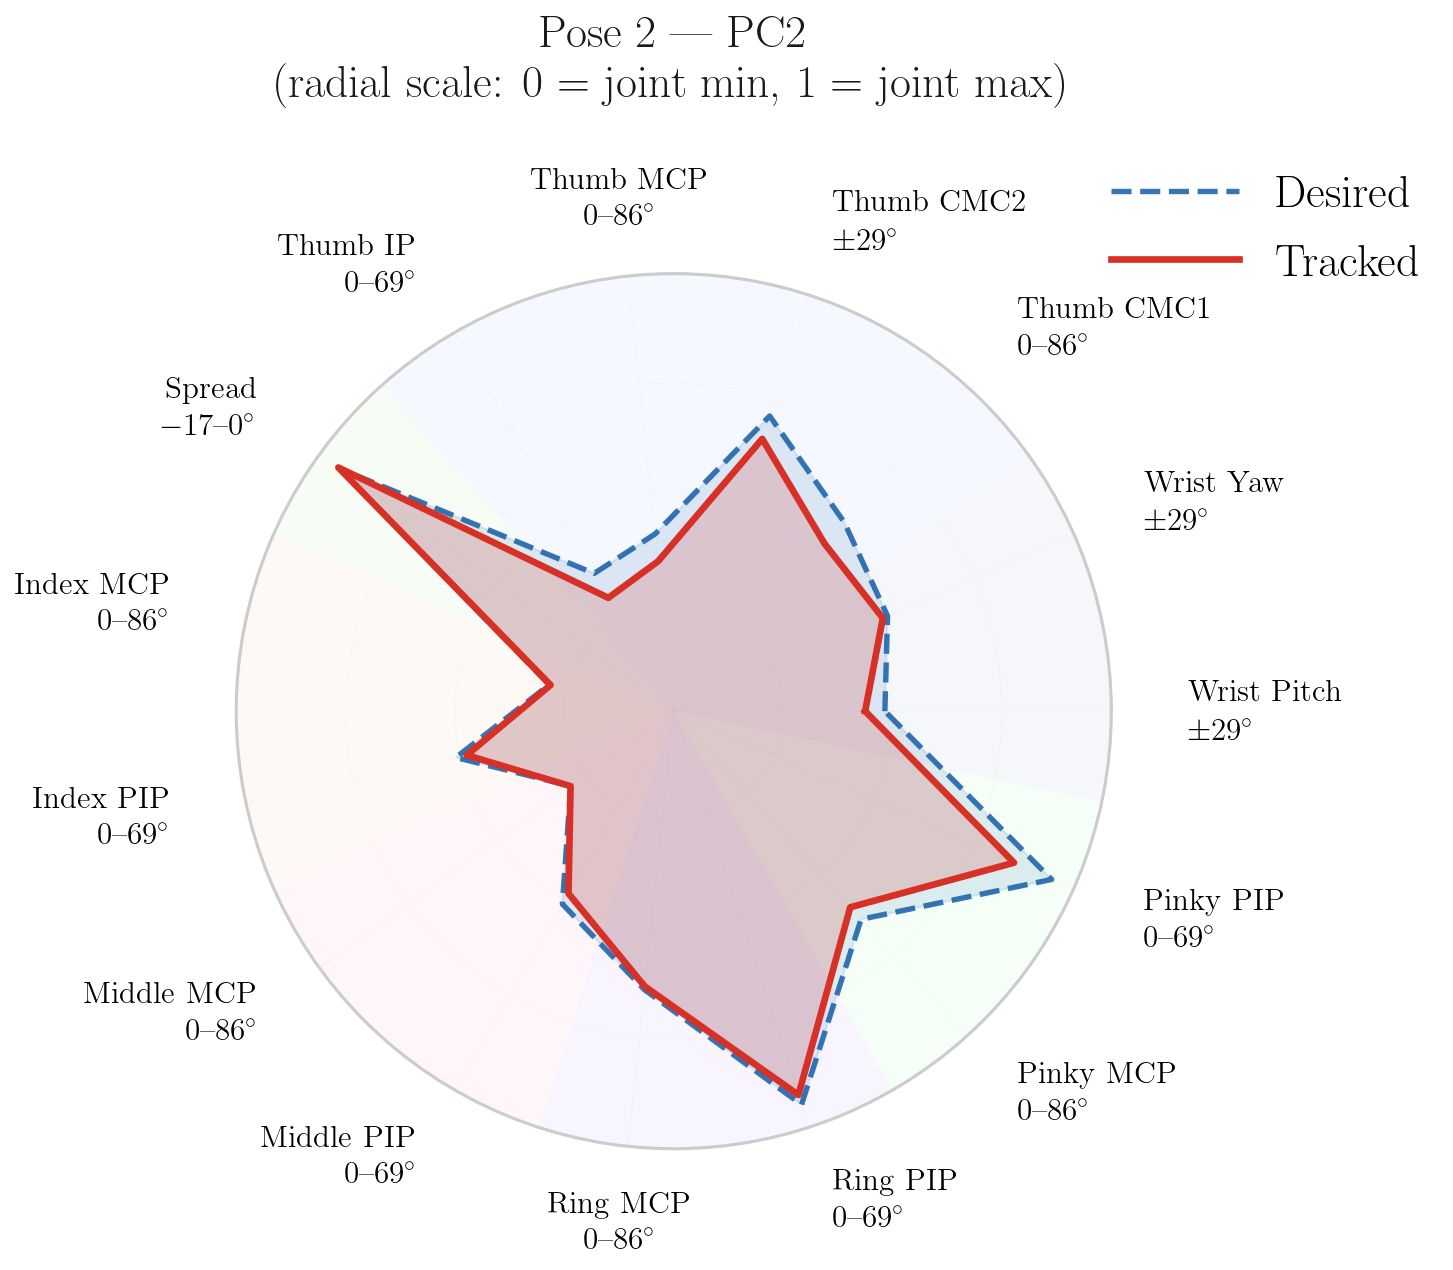

In [23]:
from ModelIDHand.hand_params import JOINT_LIMITS as _JL

_SPEC = [
    ('wrist_pitch',  'wrist_pitch',  'Wrist Pitch'),
    ('wrist_yaw',    'wrist_yaw',    'Wrist Yaw'),
    ('thumb_CMC1',   'thumb_CMC1',   'Thumb CMC1'),
    ('thumb_CMC2',   'thumb_CMC2',   'Thumb CMC2'),
    ('thumb_MCP',    'thumb_MCP',    'Thumb MCP'),
    ('thumb_IP',     'thumb_IP',     'Thumb IP'),
    ('spread_index', 'index_spread', 'Spread'),
    ('index_MCP',    'index_MCP',    'Index MCP'),
    ('index_PIP',    'index_PIP',    'Index PIP'),
    ('middle_MCP',   'middle_MCP',   'Middle MCP'),
    ('middle_PIP',   'middle_PIP',   'Middle PIP'),
    ('ring_MCP',     'ring_MCP',     'Ring MCP'),
    ('ring_PIP',     'ring_PIP',     'Ring PIP'),
    ('pinky_MCP',    'pinky_MCP',    'Pinky MCP'),
    ('pinky_PIP',    'pinky_PIP',    'Pinky PIP'),
]
_FULL_JN = [
    'wrist_pitch', 'wrist_yaw',
    'thumb_CMC1', 'thumb_CMC2', 'thumb_MCP', 'thumb_IP',
    'spread_index', 'spread_middle', 'spread_ring', 'spread_pinky',
    'index_MCP', 'index_PIP', 'index_DIP',
    'middle_MCP', 'middle_PIP', 'middle_DIP',
    'ring_MCP', 'ring_PIP', 'ring_DIP',
    'pinky_MCP', 'pinky_PIP', 'pinky_DIP',
]

_N        = len(_SPEC)
_angles   = np.linspace(0, 2*np.pi, _N, endpoint=False)
_angles_c = np.append(_angles, _angles[0])
_csv_cols = [s[0] for s in _SPEC]
_lim_keys = [s[1] for s in _SPEC]
_dtheta   = 2*np.pi / _N

# Typography controls for readability in notebook and exported PDF
_LBL_FS   = 15
_TITLE_FS = 22
_LEG_FS   = 22

# LaTeX-safe two-line labels: 'Joint Name\nrange'
def _make_lbl(name, lk):
    lo, hi = _JL[lk]
    lo_d, hi_d = int(round(np.degrees(lo))), int(round(np.degrees(hi)))
    if lo_d == 0:          r = f'$0$--${hi_d}^{{\\circ}}$'
    elif hi_d == 0:        r = f'${lo_d}$--$0^{{\\circ}}$'
    elif lo_d == -hi_d:    r = f'$\\pm {hi_d}^{{\\circ}}$'
    else:                  r = f'${lo_d}$--${hi_d}^{{\\circ}}$'
    return f'{name}\n{r}'

_rad_lbl = [_make_lbl(s[2], s[1]) for s in _SPEC]

# group sector backgrounds (start, end, fill colour)
_SECTORS = [
    (0,  2,  '#EDF1F6'),
    (2,  6,  '#EDF3FF'),
    (6,  7,  '#F1FAED'),
    (7,  9,  '#FFF5ED'),
    (9,  11, '#FFF0F5'),
    (11, 13, '#F4EDFF'),
    (13, 15, '#EDFFF4'),
]

_C_DES = '#2166AC'
_C_TRK = '#D73027'


def _normalize(jd):
    vals = []
    for col, lim in zip(_csv_cols, _lim_keys):
        lo, hi = _JL[lim]; rng = hi - lo
        vals.append(np.clip((jd[col] - lo) / rng, 0, 1) if rng > 0 else 0.5)
    return np.array(vals)


for pose_id, label in zip(POSES, LABELS):
    df     = dfs[pose_id]
    ref_jd = {j: df[f'{j}_ref_rad'].values[0]  for j in _FULL_JN}
    act_jd = {j: df[f'{j}_act_rad'].values[-1] for j in _FULL_JN}
    v_des  = _normalize(ref_jd);  v_des_c = np.append(v_des, v_des[0])
    v_trk  = _normalize(act_jd);  v_trk_c = np.append(v_trk, v_trk[0])

    fig, ax = plt.subplots(1, 1, figsize=(11, 11), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor('white')

    for s, e, col in _SECTORS:
        t = np.linspace(_angles[s] - _dtheta/2, _angles[e-1] + _dtheta/2, 80)
        ax.fill(np.concatenate([[_angles[s] - _dtheta/2], t, [_angles[e-1] + _dtheta/2]]),
                np.concatenate([[0], np.ones(80), [0]]),
                color=col, alpha=0.55, zorder=0, linewidth=0)

    ax.fill(_angles_c, v_des_c, color=_C_DES, alpha=0.12, zorder=1)
    ax.plot(_angles_c, v_des_c, lw=2.6, ls='--', color=_C_DES, alpha=0.9, zorder=2, label='Desired')
    ax.fill(_angles_c, v_trk_c, color=_C_TRK, alpha=0.18, zorder=3)
    ax.plot(_angles_c, v_trk_c, lw=3.2, ls='-',  color=_C_TRK,           zorder=4, label='Tracked')

    ax.set_xticks(_angles)
    ax.set_xticklabels(_rad_lbl, fontsize=_LBL_FS, linespacing=1.4)
    # Push side labels outward from the circle while keeping top/bottom centered.
    for txt, ang in zip(ax.get_xticklabels(), _angles):
        c = np.cos(ang)
        if c > 0.2:
            txt.set_horizontalalignment('left')
        elif c < -0.2:
            txt.set_horizontalalignment('right')
        else:
            txt.set_horizontalalignment('center')

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels([])
    ax.tick_params(axis='x', pad=24)
    ax.grid(color='0.80', linewidth=0.4, linestyle=':')
    ax.spines['polar'].set_color('#cccccc')
    ax.set_title(
        f'Pose {pose_id} — {label}\n'
        '(radial scale: 0 = joint min, 1 = joint max)',
        fontsize=_TITLE_FS, fontweight='semibold', pad=34, color='#1a1a1a')
    ax.legend(
        loc='upper right',
        bbox_to_anchor=(1.40, 1.16),
        fontsize=_LEG_FS,
        frameon=False,
        handlelength=2.8,
        labelspacing=0.6
    )

    plt.tight_layout()
    plt.savefig(os.path.join(PDF_DIR, f'pose{pose_id}_{label}_radar.pdf'),
                bbox_inches='tight', dpi=300)
    plt.show()

## Desired vs tracked hand pose

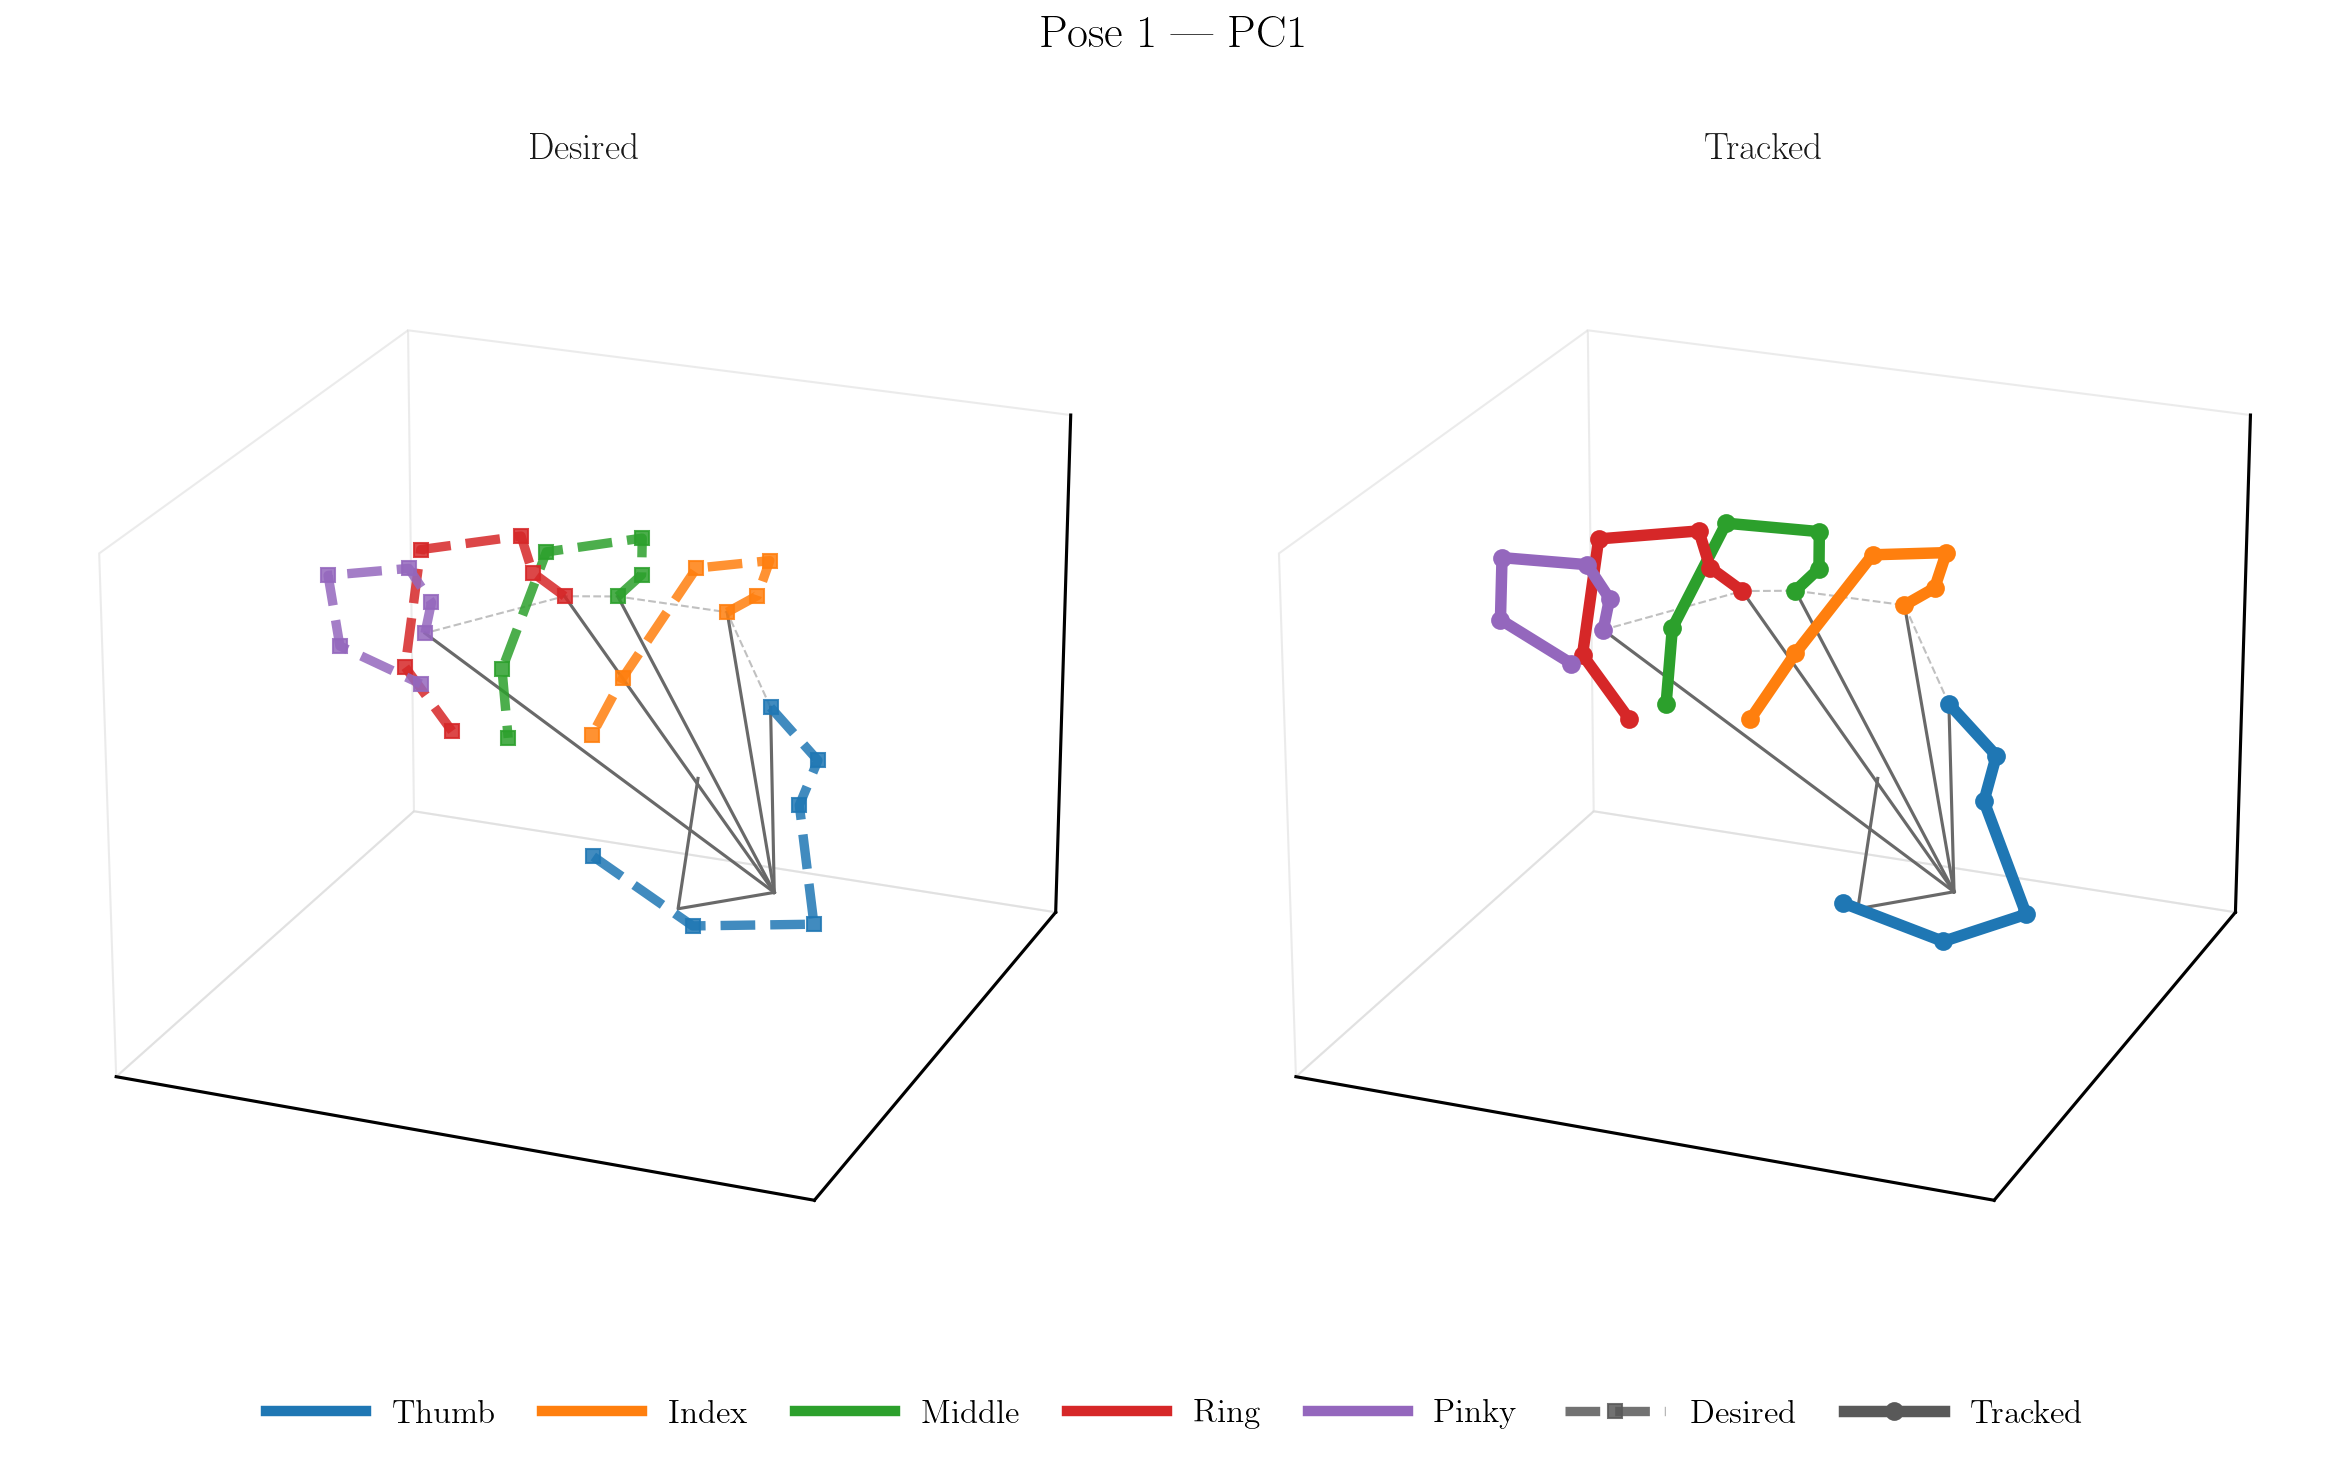

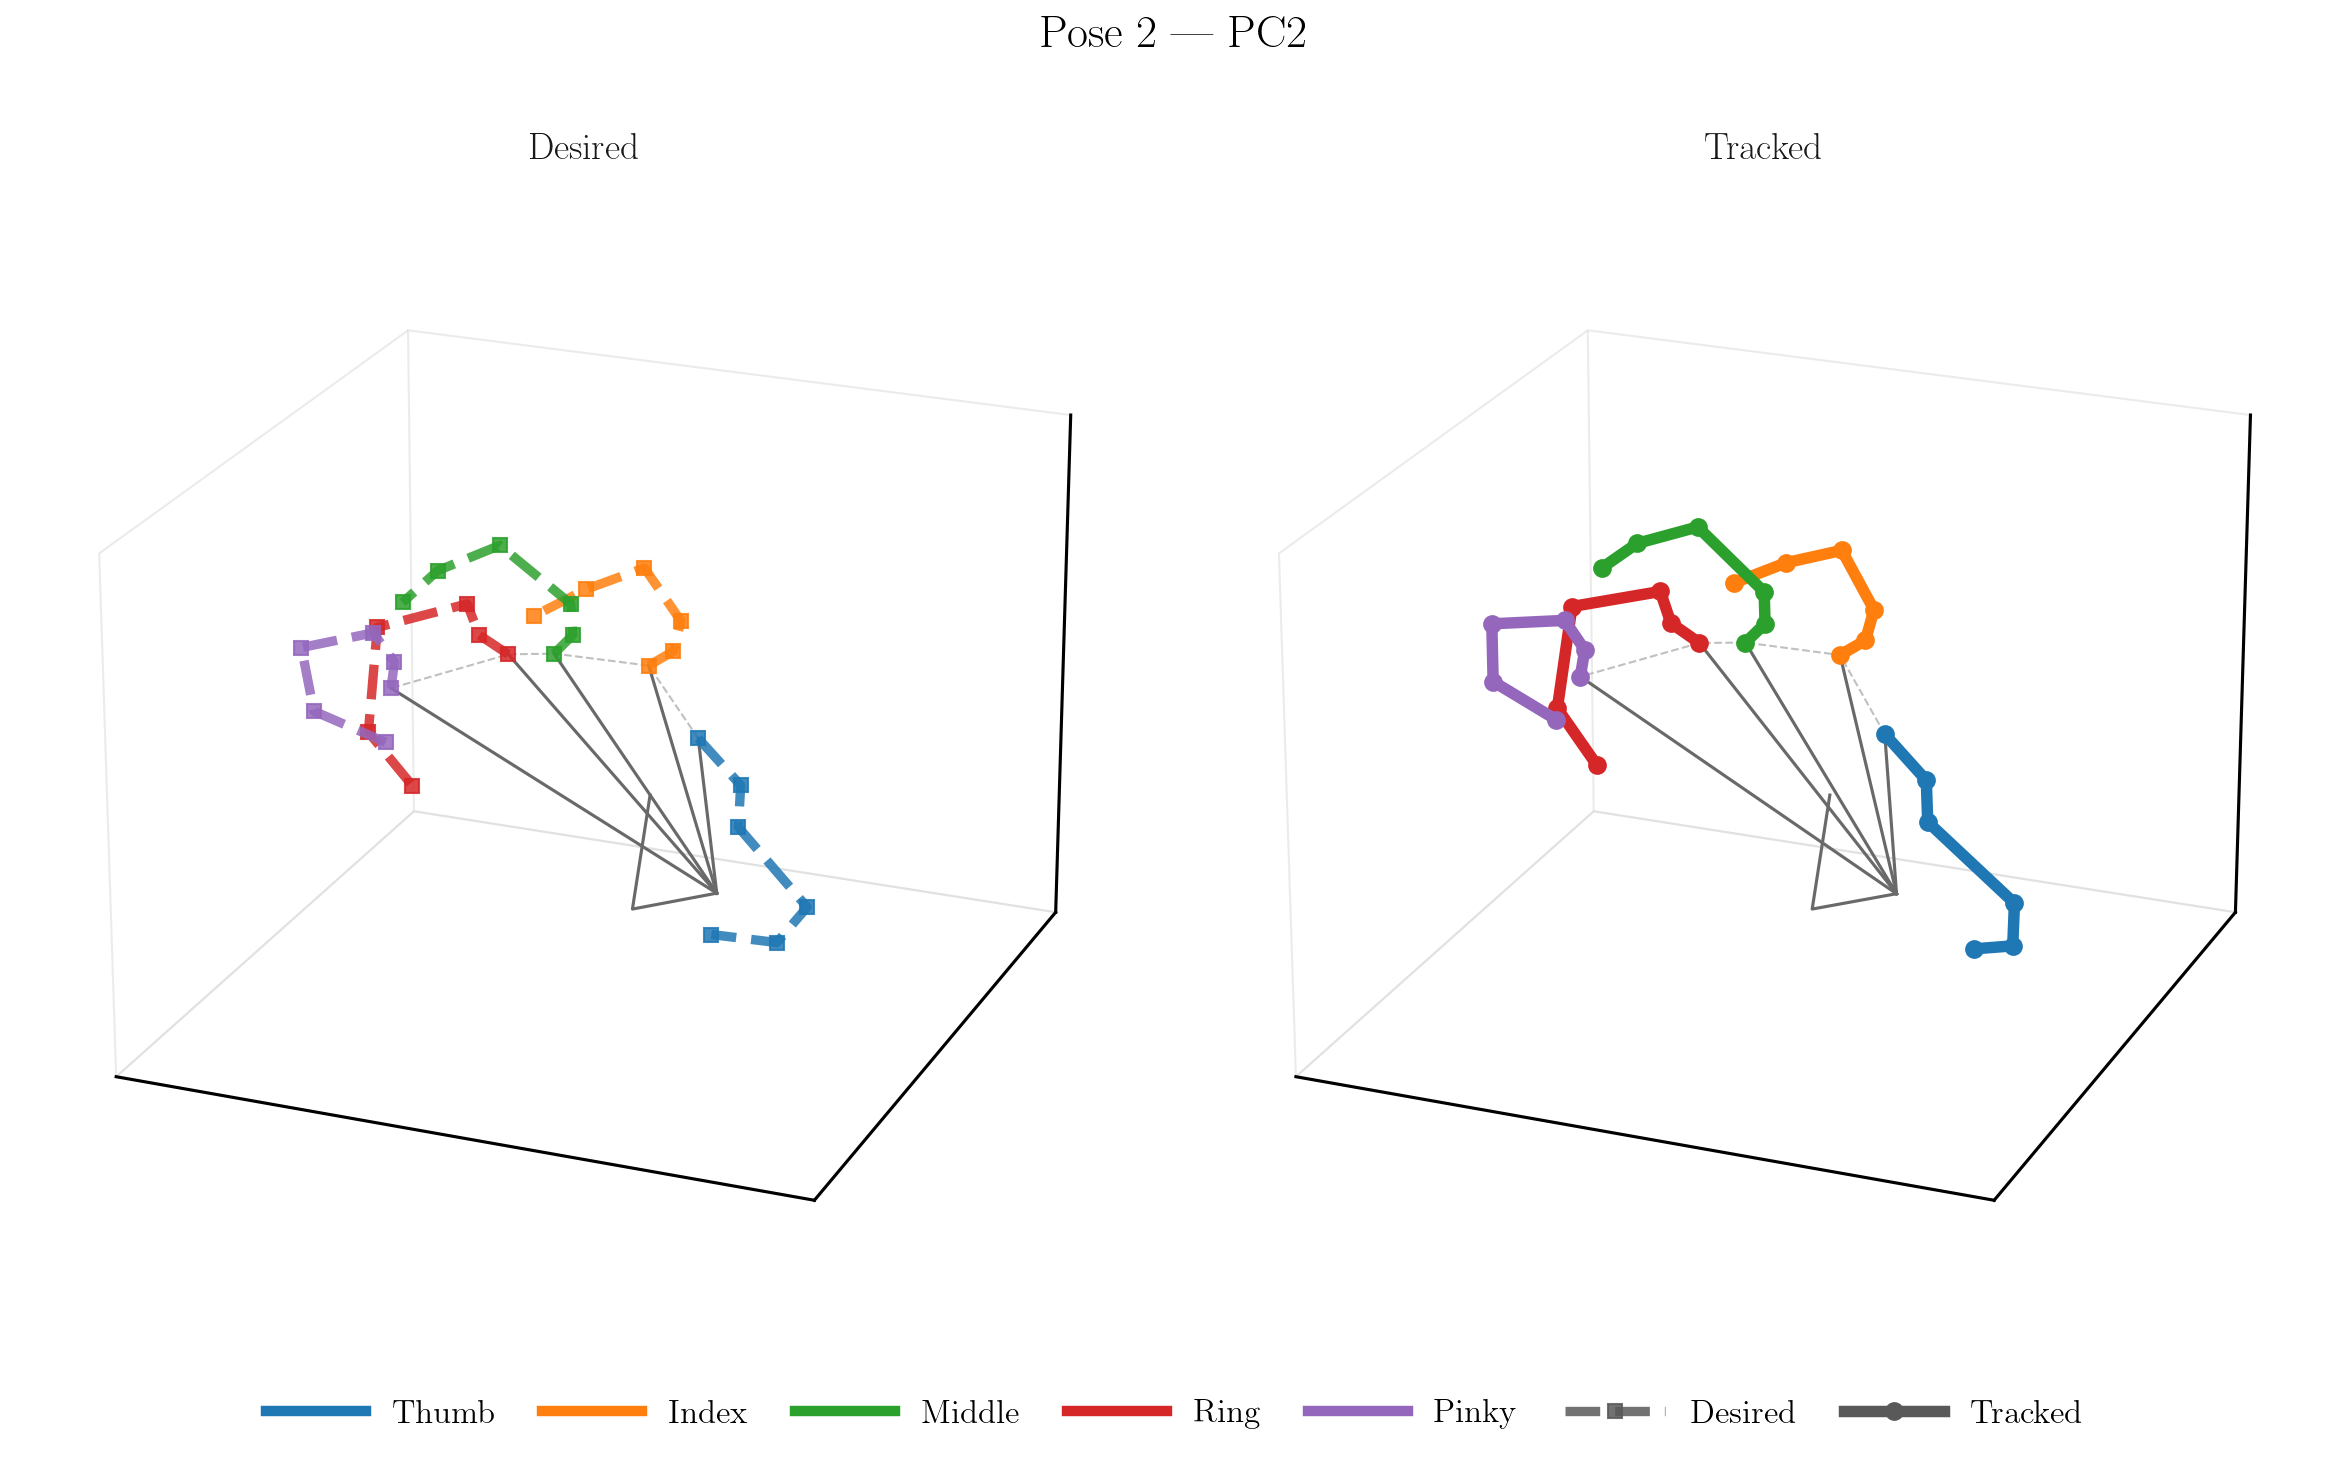

In [24]:
# Hand snapshot: Desired vs Tracked side-by-side, one figure per pose
from ModelIDHand.hand_viz import plot_hand, _COL
from KinematicsHand.FK_Hand import FK_motor2palm, joint_to_motor

_JOINT_NAMES = [
    'wrist_pitch', 'wrist_yaw',
    'thumb_CMC1', 'thumb_CMC2', 'thumb_MCP', 'thumb_IP',
    'spread_index', 'spread_middle', 'spread_ring', 'spread_pinky',
    'index_MCP', 'index_PIP', 'index_DIP',
    'middle_MCP', 'middle_PIP', 'middle_DIP',
    'ring_MCP', 'ring_PIP', 'ring_DIP',
    'pinky_MCP', 'pinky_PIP', 'pinky_DIP',
]
_FIN_ALL = ['thumb', 'index', 'middle', 'ring', 'pinky']

_STYLE_DES = dict(linestyle='--', linewidth=4.5, marker='s', markersize=7.0, alpha=0.85)
_STYLE_TRK = dict(linestyle='-',  linewidth=5.5, marker='o', markersize=8.0)
_ELEV, _AZIM = 22, 112


def _polish_ax(ax, title, show_palm_vector=False, q_motor=None):
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel('');  ax.set_ylabel('');  ax.set_zlabel('')
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = False
        pane.set_edgecolor('#d8d8d8')
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis._axinfo['grid']['color']     = (0.88, 0.88, 0.88, 0.6)
        axis._axinfo['grid']['linewidth'] = 0.4
    ax.view_init(elev=_ELEV, azim=_AZIM)
    ax.set_title(title, fontsize=18, fontweight='semibold', pad=14, color='#1a1a1a')
    if show_palm_vector and q_motor is not None:
        R_palm, p_palm = FK_motor2palm(q_motor, np.array([0, 0, 0]))
        palm_normal = R_palm @ np.array([0, 0, 1])
        ax.quiver(p_palm[0], p_palm[1], p_palm[2],
                 palm_normal[0]*0.05, palm_normal[1]*0.05, palm_normal[2]*0.05,
                 color='red', arrow_length_ratio=0.3, linewidth=2.5, alpha=0.8)


def _sync_pair(ax1, ax2):
    xl = [min(ax1.get_xlim3d()[0], ax2.get_xlim3d()[0]), max(ax1.get_xlim3d()[1], ax2.get_xlim3d()[1])]
    yl = [min(ax1.get_ylim3d()[0], ax2.get_ylim3d()[0]), max(ax1.get_ylim3d()[1], ax2.get_ylim3d()[1])]
    zl = [min(ax1.get_zlim3d()[0], ax2.get_zlim3d()[0]), max(ax1.get_zlim3d()[1], ax2.get_zlim3d()[1])]
    span = max(xl[1]-xl[0], yl[1]-yl[0], zl[1]-zl[0])
    cx, cy, cz = 0.5*(xl[0]+xl[1]), 0.5*(yl[0]+yl[1]), 0.5*(zl[0]+zl[1])
    for ax in (ax1, ax2):
        ax.set_xlim3d(cx - span/2, cx + span/2)
        ax.set_ylim3d(cy - span/2, cy + span/2)
        ax.set_zlim3d(cz - span/2, cz + span/2)


_LEG = (
    [plt.Line2D([0],[0], color=_COL[n], lw=5.0, ls='-', label=n.capitalize()) for n in _FIN_ALL]
    + [plt.Line2D([0],[0], color='0.35', lw=4.5, ls='--', marker='s', ms=7.0, alpha=0.85, label='Desired'),
       plt.Line2D([0],[0], color='0.35', lw=5.5, ls='-',  marker='o', ms=8.0, label='Tracked')]
)

for pose_id, label in zip(POSES, LABELS):
    df = dfs[pose_id]
    ref_jd = {j: df[f'{j}_ref_rad'].values[0]  for j in _JOINT_NAMES}
    act_jd = {j: df[f'{j}_act_rad'].values[-1] for j in _JOINT_NAMES}
    
    q_ref = joint_to_motor(
        np.array([ref_jd['wrist_pitch'], ref_jd['wrist_yaw']]),
        np.array([ref_jd['thumb_CMC1'], ref_jd['thumb_CMC2'], ref_jd['thumb_MCP'], ref_jd['thumb_IP']]),
        ref_jd['spread_index'],
        np.array([ref_jd['index_MCP'], ref_jd['index_PIP']]),
        np.array([ref_jd['middle_MCP'], ref_jd['middle_PIP']]),
        np.array([ref_jd['ring_MCP'], ref_jd['ring_PIP']]),
        np.array([ref_jd['pinky_MCP'], ref_jd['pinky_PIP']]),
    )
    q_act = joint_to_motor(
        np.array([act_jd['wrist_pitch'], act_jd['wrist_yaw']]),
        np.array([act_jd['thumb_CMC1'], act_jd['thumb_CMC2'], act_jd['thumb_MCP'], act_jd['thumb_IP']]),
        act_jd['spread_index'],
        np.array([act_jd['index_MCP'], act_jd['index_PIP']]),
        np.array([act_jd['middle_MCP'], act_jd['middle_PIP']]),
        np.array([act_jd['ring_MCP'], act_jd['ring_PIP']]),
        np.array([act_jd['pinky_MCP'], act_jd['pinky_PIP']]),
    )

    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor('white')
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')

    plot_hand(q_ref, ax=ax1, style=_STYLE_DES)
    plot_hand(q_act, ax=ax2, style=_STYLE_TRK)

    _polish_ax(ax1, 'Desired', show_palm_vector=False)
    _polish_ax(ax2, 'Tracked', show_palm_vector=False)
    _sync_pair(ax1, ax2)

    for ax in (ax1, ax2):
        leg = ax.get_legend()
        if leg: leg.remove()

    fig.legend(handles=_LEG, loc='lower center', ncol=8,
               fontsize=16, frameon=False, bbox_to_anchor=(0.5, -0.05),
               handlelength=3.0, columnspacing=1.4)
    fig.suptitle(f'Pose {pose_id} — {label}', fontsize=22, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(PDF_DIR, f'pose{pose_id}_{label}_hand_viz.pdf'), bbox_inches='tight', dpi=300)
    plt.show()